# Amazon Sales Data Analysis
## Data Science ToolBox: Python Programming
**Course Code:** INT 375 | 


In [13]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


## Loading the Dataset

In [14]:
# Loading the Amazon Sales dataset
df = pd.read_csv('amazon.csv')

print("Shape of dataset:", df.shape)
df.head(10)

Shape of dataset: (500, 9)


,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product
0,B000000000,Amazon Product 1,Sports|Fitness,"₹1,199","₹1,499",20%,4.4,"49,567",Sample product description.
1,B000000001,Amazon Product 2,Computers&Accessories|Mouse,"₹25,499","₹29,999",15%,3.3,"48,405",Sample product description.
2,B000000002,Amazon Product 3,Sports|Outdoor,"₹10,499","₹29,999",65%,4.0,"9,916",Sample product description.
3,B000000003,Amazon Product 4,HomeKitchen|Cookware,"₹17,999","₹19,999",10%,4.0,"4,581",Sample product description.
4,B000000004,Amazon Product 5,Sports|Fitness,"₹2,999","₹4,999",40%,4.4,"45,504",Sample product description.
5,B000000005,Amazon Product 6,Books|Academic,"₹17,999","₹29,999",40%,3.3,"38,148",Sample product description.
6,B000000006,Amazon Product 7,Computers&Accessories|Keyboards,₹174,₹499,65%,4.7,"38,328",Sample product description.
7,B000000007,Amazon Product 8,Sports|Fitness,"₹2,549","₹2,999",15%,4.1,"28,188",Sample product description.
8,B000000008,Amazon Product 9,Sports|Outdoor,₹899,"₹1,499",40%,4.1,"27,115",Sample product description.
9,B000000009,Amazon Product 10,HomeKitchen|Cookware,₹899,"₹2,999",70%,3.8,"30,006",Sample product description.


In [15]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_id           500 non-null    object 
 1   product_name         500 non-null    object 
 2   category             500 non-null    object 
 3   discounted_price     500 non-null    object 
 4   actual_price         500 non-null    object 
 5   discount_percentage  500 non-null    object 
 6   rating               500 non-null    float64
 7   rating_count         500 non-null    object 
 8   about_product        500 non-null    object 
dtypes: float64(1), object(8)
memory usage: 35.3+ KB


In [16]:
# Statistical Summary
df.describe()

,rating
count,500.000000
mean,3.993000
std,0.472119
min,2.600000
25%,3.700000
50%,4.000000
75%,4.300000
max,5.000000


In [17]:
# Checking for null values
print("Null values in each column:")
print(df.isnull().sum())

Null values in each column:
product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           0
about_product          0
dtype: int64


## Data Cleaning & Preprocessing

In [18]:
# Cleaning the 'discounted_price' column - removing ₹ and commas
df['discounted_price'] = df['discounted_price'].astype(str).str.replace('₹','').str.replace(',','').str.strip()
df['discounted_price'] = pd.to_numeric(df['discounted_price'], errors='coerce')

# Cleaning the 'actual_price' column
df['actual_price'] = df['actual_price'].astype(str).str.replace('₹','').str.replace(',','').str.strip()
df['actual_price'] = pd.to_numeric(df['actual_price'], errors='coerce')

# Cleaning the 'discount_percentage' column
df['discount_percentage'] = df['discount_percentage'].astype(str).str.replace('%','').str.strip()
df['discount_percentage'] = pd.to_numeric(df['discount_percentage'], errors='coerce')

# Cleaning the 'rating' column
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

# Cleaning the 'rating_count' column
df['rating_count'] = df['rating_count'].astype(str).str.replace(',','').str.strip()
df['rating_count'] = pd.to_numeric(df['rating_count'], errors='coerce')

# Drop rows with all nulls
df.dropna(how='all', inplace=True)

print("Data cleaned successfully!")
print("Shape after cleaning:", df.shape)
df.head()

Data cleaned successfully!
Shape after cleaning: (500, 9)


,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product
0,B000000000,Amazon Product 1,Sports|Fitness,1199,1499,20,4.4,49567,Sample product description.
1,B000000001,Amazon Product 2,Computers&Accessories|Mouse,25499,29999,15,3.3,48405,Sample product description.
2,B000000002,Amazon Product 3,Sports|Outdoor,10499,29999,65,4.0,9916,Sample product description.
3,B000000003,Amazon Product 4,HomeKitchen|Cookware,17999,19999,10,4.0,4581,Sample product description.
4,B000000004,Amazon Product 5,Sports|Fitness,2999,4999,40,4.4,45504,Sample product description.


In [19]:
# Extracting main category from 'category' column
df['main_category'] = df['category'].astype(str).apply(lambda x: x.split('|')[0].strip())

print("Unique main categories:")
print(df['main_category'].value_counts())

Unique main categories:
main_category
Sports                   106
Computers&Accessories    105
Electronics              103
Books                     98
HomeKitchen               88
Name: count, dtype: int64


---
## Objective 1: Distribution of Products by Category

### Introduction
This analysis shows which product categories have the most listings on Amazon.

### Functions Used
- `value_counts()` – count products per category
- `plt.pie()` – pie chart for proportional view
- `autopct='%1.1f%%'` – show percentage on each slice


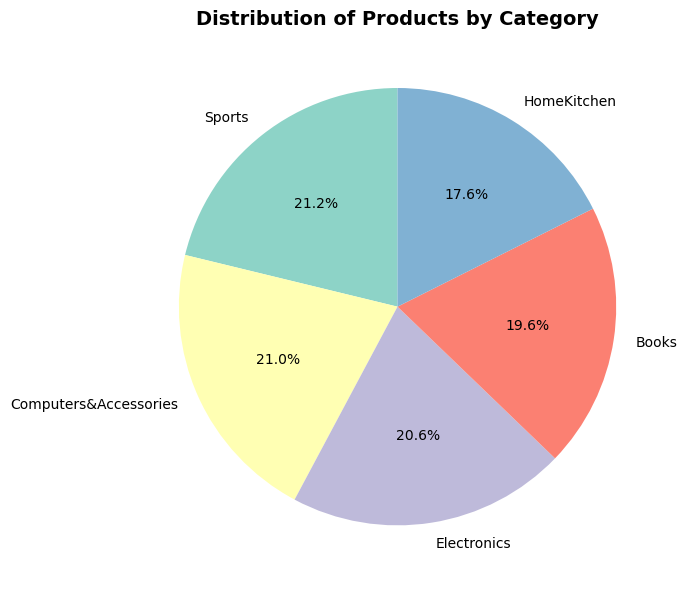

Top categories:
main_category
Sports                   106
Computers&Accessories    105
Electronics              103
Books                     98
HomeKitchen               88
Name: count, dtype: int64


In [20]:
# 1. Distribution of Products by Category
category_counts = df['main_category'].value_counts().head(8)

plt.figure(figsize=(8, 6))
plt.pie(category_counts, labels=category_counts.index,
        autopct='%1.1f%%', startangle=90,
        colors=plt.cm.Set3.colors)
plt.title("Distribution of Products by Category", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Top categories:")
print(category_counts)

---
## Objective 2: Average Discounted Price by Category

### Introduction
Compare the average selling price across different categories to understand pricing patterns.

### Functions Used
- `groupby()` – group data by category
- `mean()` – calculate average price
- `sort_values()` – rank by price
- `plt.bar()` – bar chart for comparison


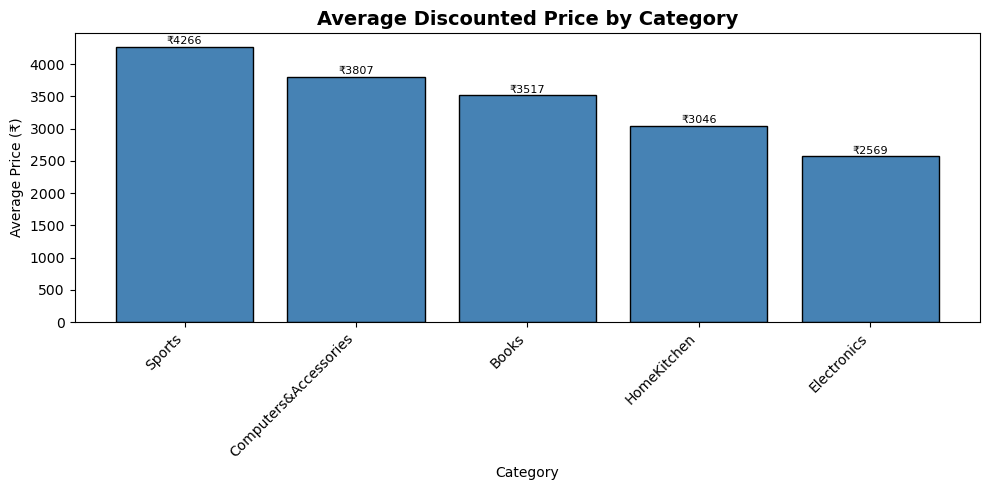

In [21]:
# 2. Average Discounted Price by Category
avg_price = df.groupby('main_category')['discounted_price'].mean().sort_values(ascending=False).head(8)

plt.figure(figsize=(10, 5))
bars = plt.bar(avg_price.index, avg_price.values, color='steelblue', edgecolor='black')
plt.title("Average Discounted Price by Category", fontsize=14, fontweight='bold')
plt.xlabel("Category")
plt.ylabel("Average Price (₹)")
plt.xticks(rotation=45, ha='right')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             f'₹{bar.get_height():.0f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

---
## Objective 3: Relationship Between Discount % and Rating

### Introduction
This scatter plot explores whether products with higher discounts tend to receive better or worse customer ratings.

### Functions Used
- `sns.scatterplot()` – scatter plot with hue
- `hue='main_category'` – color points by category
- `alpha=0.6` – transparency for overlapping points


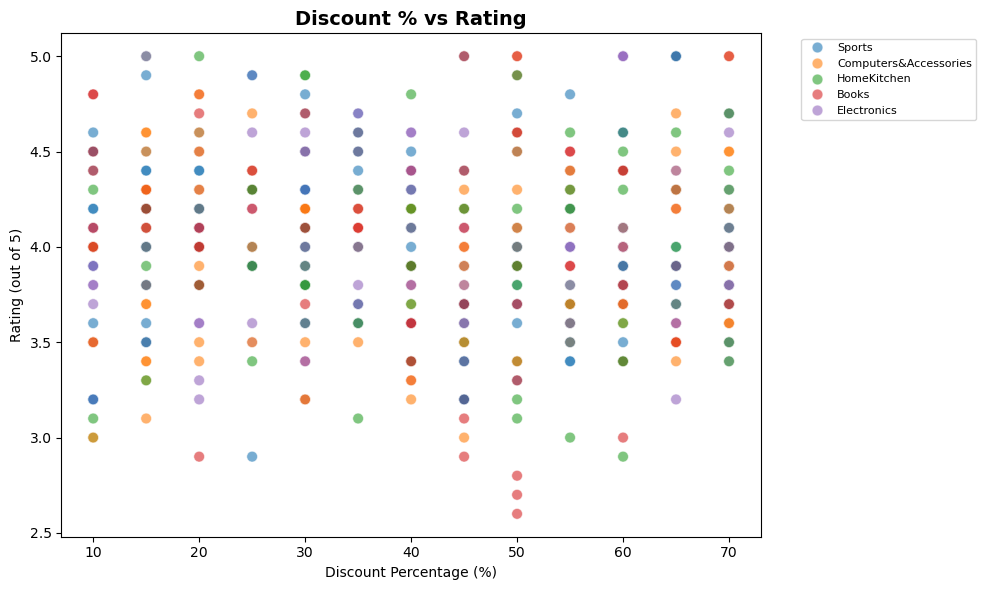

In [22]:
# 3. Scatter Plot: Discount % vs Rating
plt.figure(figsize=(10, 6))
sns.scatterplot(x='discount_percentage', y='rating',
                data=df.dropna(subset=['discount_percentage','rating']),
                hue='main_category', alpha=0.6, s=60)
plt.title("Discount % vs Rating", fontsize=14, fontweight='bold')
plt.xlabel("Discount Percentage (%)")
plt.ylabel("Rating (out of 5)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

---
## Objective 4: Outlier Detection in Actual Price using Boxplot

### Introduction
Detect pricing outliers across categories using boxplots. Outliers indicate unusually expensive or cheap products.

### Functions Used
- `sns.boxplot()` – shows median, IQR, and outliers
- `IQR Method`: Lower = Q1 - 1.5×IQR, Upper = Q3 + 1.5×IQR
- `df.quantile()` – calculate Q1 and Q3


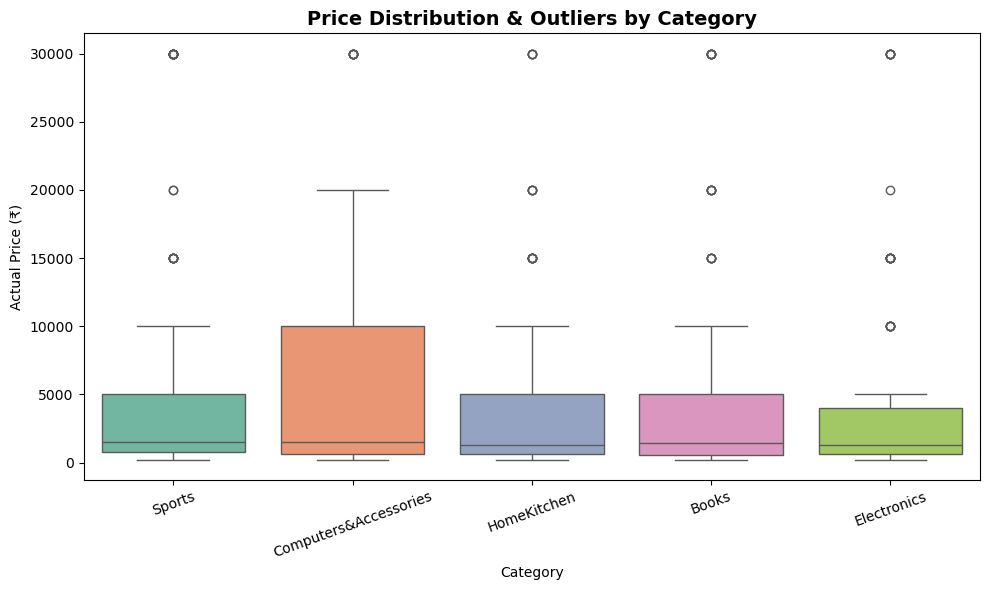

Q1: ₹599.00 | Q3: ₹4999.00 | IQR: ₹4400.00
Lower Bound: ₹-6001.00 | Upper Bound: ₹11599.00
Total Outliers detected: 92


In [23]:
# 4. Boxplot for Outlier Detection in Actual Price
top_cats = df['main_category'].value_counts().head(5).index
df_top = df[df['main_category'].isin(top_cats)]

plt.figure(figsize=(10, 6))
sns.boxplot(x='main_category', y='actual_price', data=df_top, palette='Set2')
plt.title("Price Distribution & Outliers by Category", fontsize=14, fontweight='bold')
plt.xlabel("Category")
plt.ylabel("Actual Price (₹)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# IQR Calculation
Q1 = df['actual_price'].quantile(0.25)
Q3 = df['actual_price'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[(df['actual_price'] < lower) | (df['actual_price'] > upper)]
print(f"Q1: ₹{Q1:.2f} | Q3: ₹{Q3:.2f} | IQR: ₹{IQR:.2f}")
print(f"Lower Bound: ₹{lower:.2f} | Upper Bound: ₹{upper:.2f}")
print(f"Total Outliers detected: {len(outliers)}")

---
## Objective 5: Correlation Heatmap

### Introduction
Understand how numeric features like price, discount, rating, and rating count relate to each other.

### Functions Used
- `.corr()` – pairwise Pearson correlation
- `sns.heatmap()` – color-coded matrix
- `annot=True` – show values in each cell
- `cmap='coolwarm'` – red for positive, blue for negative


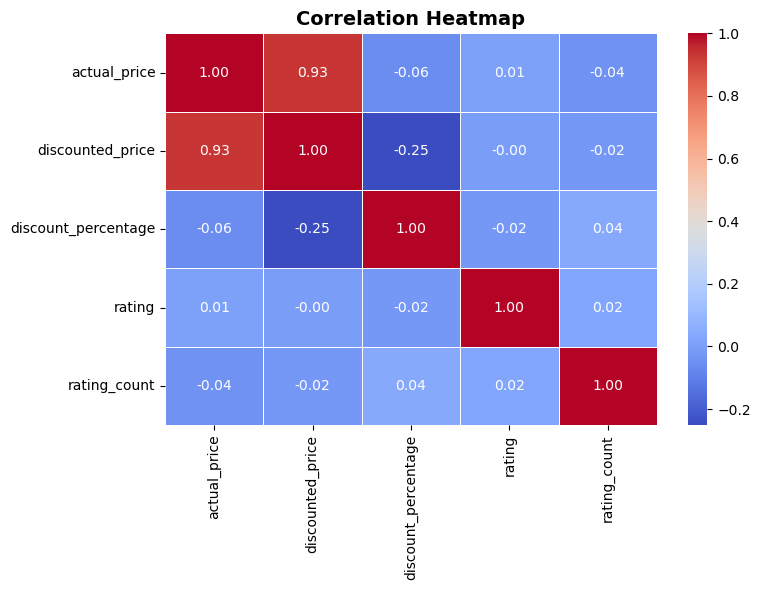

Correlation Matrix:
                     actual_price  discounted_price  discount_percentage  \
actual_price                 1.00              0.93                -0.06   
discounted_price             0.93              1.00                -0.25   
discount_percentage         -0.06             -0.25                 1.00   
rating                       0.01             -0.00                -0.02   
rating_count                -0.04             -0.02                 0.04   

                     rating  rating_count  
actual_price           0.01         -0.04  
discounted_price      -0.00         -0.02  
discount_percentage   -0.02          0.04  
rating                 1.00          0.02  
rating_count           0.02          1.00  


In [24]:
# 5. Correlation Heatmap
num_cols = ['actual_price', 'discounted_price', 'discount_percentage', 'rating', 'rating_count']
corr = df[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Correlation Matrix:")
print(corr.round(2))

---
## Conclusion

This project performed an Exploratory Data Analysis (EDA) on the Amazon Sales dataset using Python.

**Key Findings:**
- Electronics and Computers dominate the product listings
- Higher discounts do not always lead to better ratings
- Actual price has several outliers — premium products skew the distribution
- Rating count and discounted price show a weak positive correlation
- Most products are rated between 3.5 and 4.5 stars

**Tools Used:** Pandas, NumPy, Matplotlib, Seaborn

## References
- Dataset: https://www.kaggle.com/datasets/karkavelrajaj/amazon-sales-dataset
- Pandas Docs: https://pandas.pydata.org/docs/
- Seaborn Docs: https://seaborn.pydata.org/
- Matplotlib Docs: https://matplotlib.org/
